In [1]:
import matplotlib
matplotlib.use("Agg")
import plotly.io as pio
pio.renderers.default = "png"

# Plotting: plotly & plotnine

Every plotting function in `moderndive` takes an `engine=` argument:

- `engine="plotly"` (**default**) — interactive figures (`plotly.graph_objects.Figure`).
- `engine="plotnine"` — grammar-of-graphics figures (`plotnine.ggplot`).

The composition syntax is identical across engines, so you can switch a whole
analysis by changing one argument.

```{note}
The figures on this page are **static images** so they render in the docs. In a
notebook or script, the default `engine="plotly"` produces **interactive**
figures (hover, zoom, pan).
```

In [2]:
import moderndive as md
from moderndive import (
    specify, observe, get_confidence_interval,
    visualize, shade_confidence_interval, shade_p_value,
)

boot = (
    md.load_almonds_sample_100().specify(response="weight")
    .generate(reps=1000, type="bootstrap", seed=1)
    .calculate(stat="mean")
)
ci = get_confidence_interval(boot, level=0.95, type="percentile")
ci

lower_ci,upper_ci
f64,f64
3.606975,3.75


## visualize() returns an InferPlot

`visualize()` returns a small `InferPlot` wrapper that you compose with shading via
`+` in **both** engines. The underlying figure is on `.figure` (and, for plotnine,
the raw `ggplot` on `.gg`).

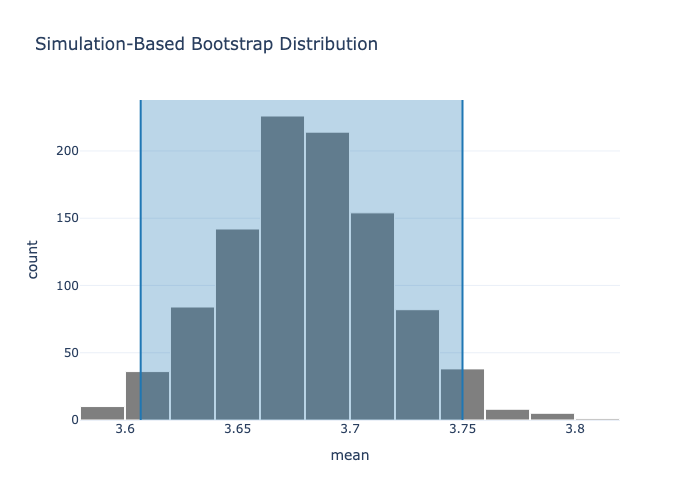

In [3]:
visualize(boot) + shade_confidence_interval(ci)

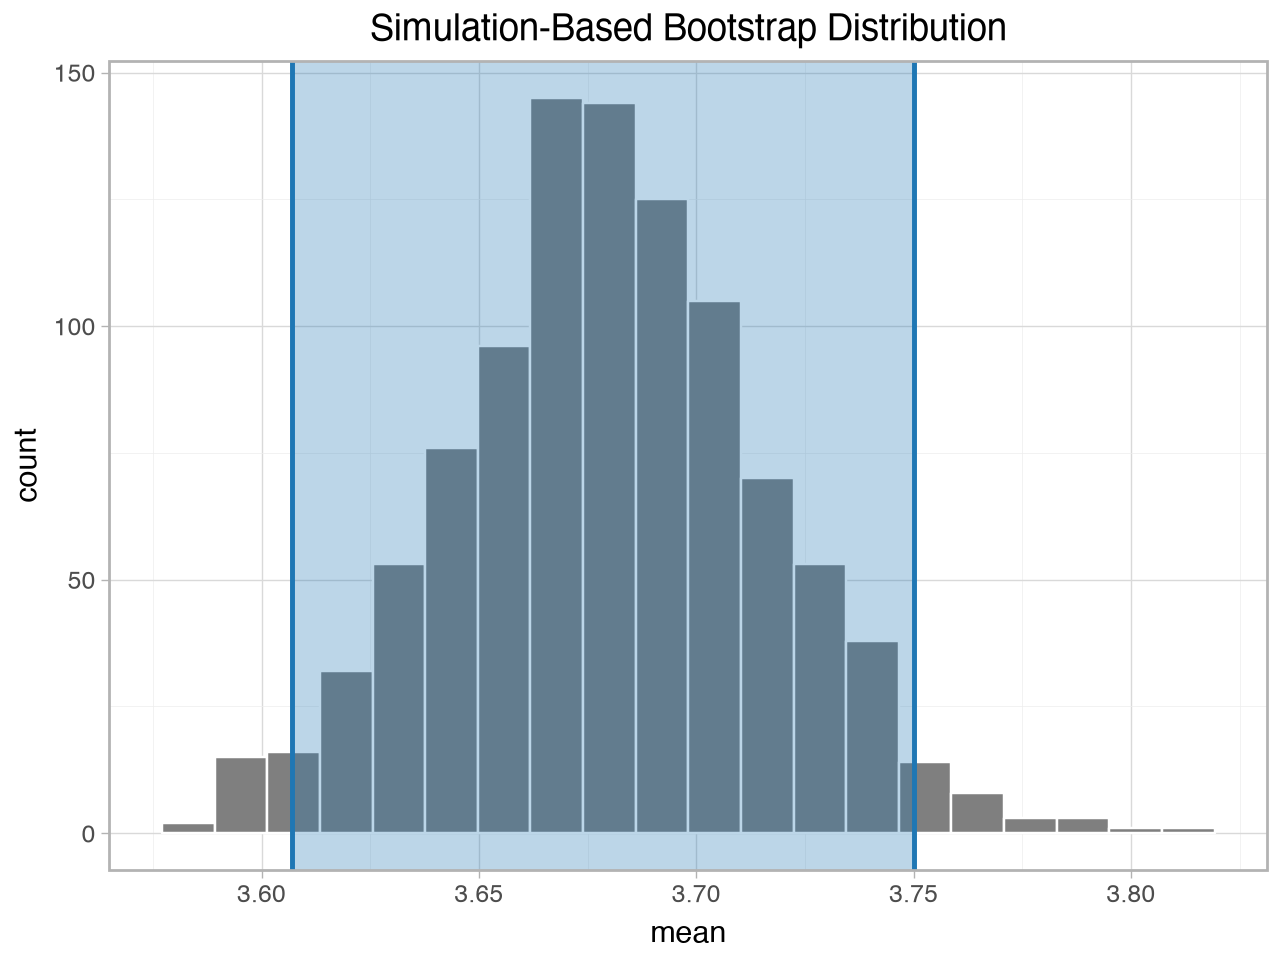

In [4]:
# the same plot via the plotnine engine
visualize(boot, engine="plotnine") + shade_confidence_interval(ci)

### Keyword form

If you'd rather not use `+`, pass the shading inline (handy for plotly):

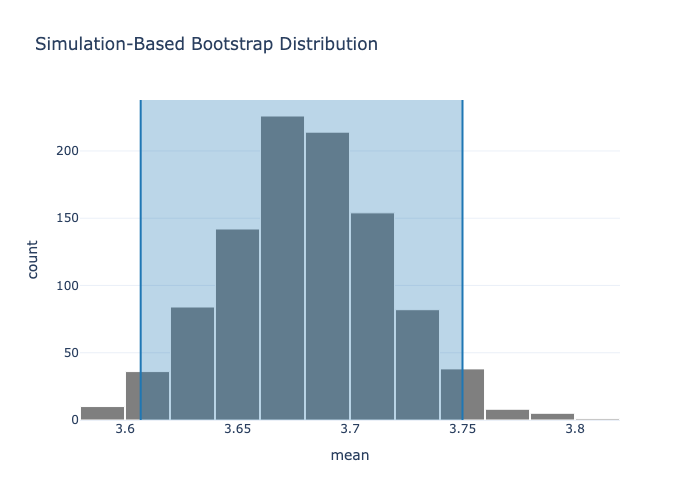

In [5]:
visualize(boot, shade_ci=ci)

## Shading p-values

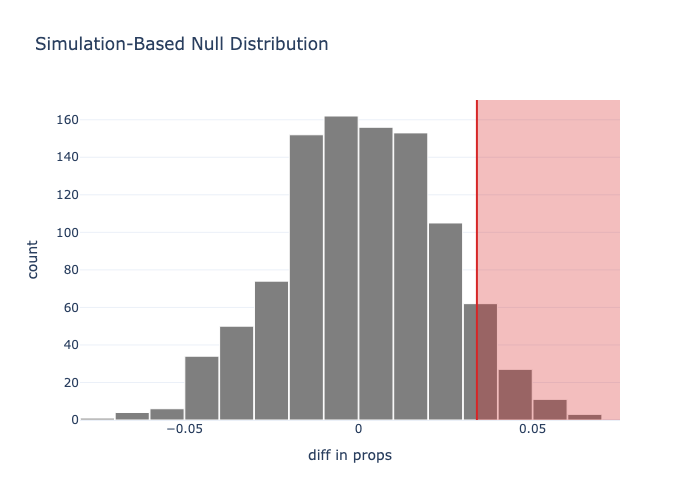

In [6]:
spotify = md.load_spotify_metal_deephouse()
obs = observe(spotify, formula="popular_or_not ~ track_genre", success="popular",
              stat="diff in props", order=("metal", "deep-house"))
null = (
    spotify.specify(formula="popular_or_not ~ track_genre", success="popular")
    .hypothesize(null="independence")
    .generate(reps=1000, type="permute", seed=76)
    .calculate(stat="diff in props", order=("metal", "deep-house"))
)
visualize(null) + shade_p_value(obs_stat=obs, direction="right")

## Simulation vs. theory overlays

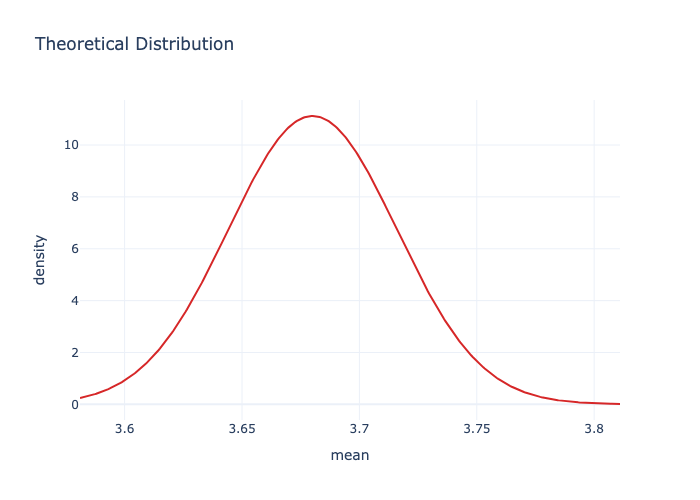

In [7]:
visualize(boot, method="theoretical")   # normal-approximation curve

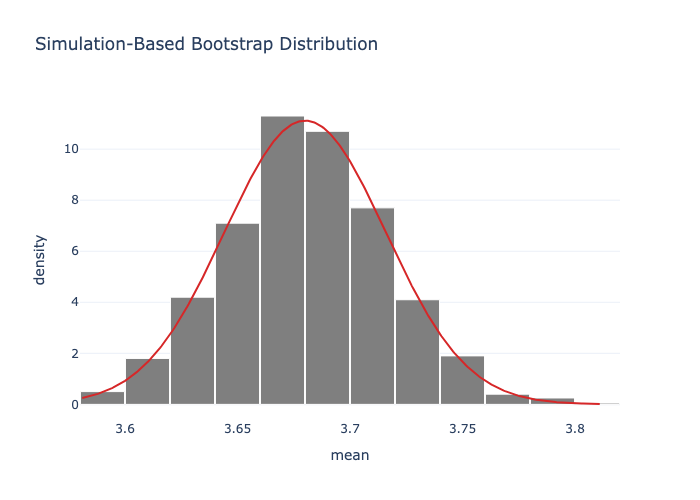

In [8]:
visualize(boot, method="both")          # histogram + curve overlaid

## Faceted regression-coefficient plots

`visualize_fit` shows one panel per term, and shading is **per-facet**:

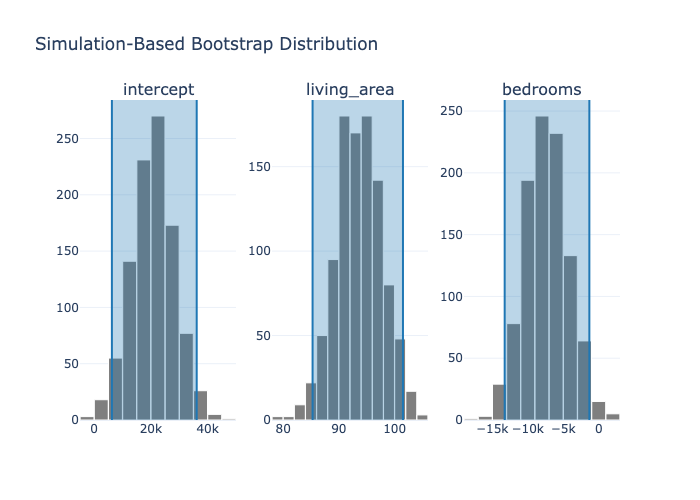

In [9]:
from moderndive.infer.viz import visualize_fit

houses = md.load_saratoga_houses()
boot_fit = (
    houses.specify(formula="price ~ living_area + bedrooms")
    .generate(reps=1000, type="bootstrap", seed=1)
    .fit()
)
visualize_fit(boot_fit) + shade_confidence_interval(boot_fit.get_confidence_interval())

## Model plots

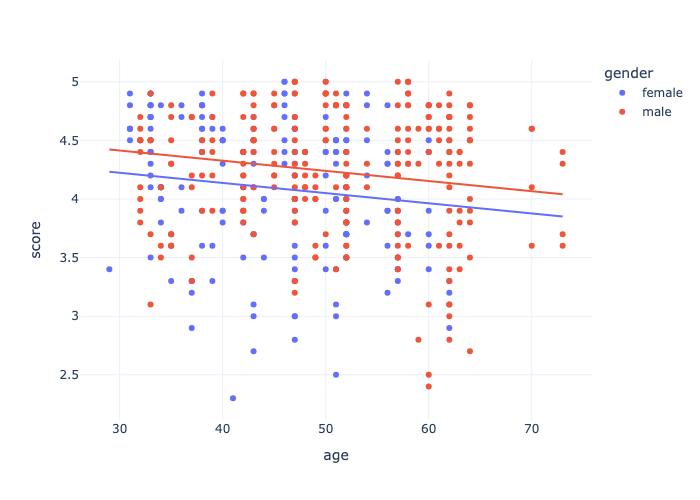

In [10]:
from moderndive import gg_parallel_slopes

evals = md.load_evals()
gg_parallel_slopes(evals, response="score", explanatory="age", by="gender")

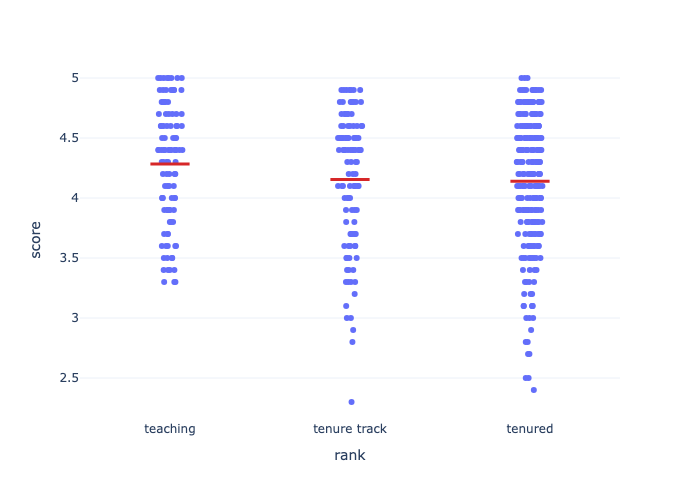

In [11]:
from moderndive import gg_categorical_model

gg_categorical_model(evals, response="score", explanatory="rank")

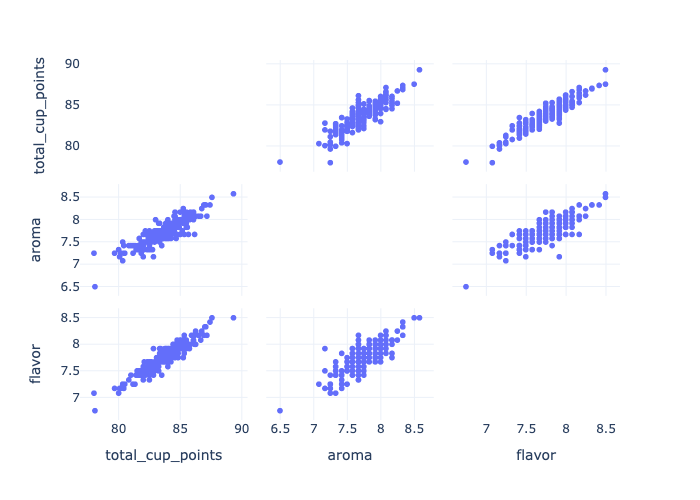

In [12]:
from moderndive import pairplot

# Scatterplot matrix (~ GGally::ggpairs)
pairplot(md.load_coffee_quality(), columns=["total_cup_points", "aroma", "flavor"])

## Saving figures

```python
p = visualize(boot)            # plotly
p.save("dist.html")            # interactive HTML (no extra deps)
p.save("dist.png")             # static image — needs: pip install "moderndive[image]"

g = visualize(boot, engine="plotnine")
g.save("dist.png", width=6, height=4, dpi=150)
```

`pairplot(..., engine="seaborn")` (alias `"plotnine"`) returns a Matplotlib figure
if you prefer the seaborn-backed scatterplot matrix.